# Rossmann Filial-Performance · Analyse

**Business Data Analyst · Rossmann-Zentrale**

Dieses Notebook analysiert die Verkaufsdaten von 1.115 Rossmann-Filialen über
ca. 2,5 Jahre und beantwortet sechs strategische Fragen des Managements:

1. **Filial-Performance** – Welche Filialen performen am besten und warum?
2. **Standortfaktoren** – Wie beeinflussen Wettbewerb und Lage den Umsatz?
3. **Saisonalität** – Welche saisonalen Muster gibt es?
4. **Feiertage & Schulferien** – Wie wirken sie auf den Umsatz?
5. **Promotionen** – Welche Aktionen sind am effektivsten?
6. **Filialtyp-Vergleich** – Welche Unterschiede zwischen Store-Typen?

**Workflow:** Laden → Datenqualität → Bereinigung & Merge → Analysen Q1–Q6 →
Management-KPIs → Export einer Tableau-fertigen CSV.

> *Hinweis:* Dieses Notebook ist als datenbasierte Entscheidungsgrundlage gedacht,
> nicht als verbindliche betriebswirtschaftliche Beratung.

## 0 · Setup & Konfiguration

Wir laden die Bibliotheken und legen die Pfade fest. `USE_KAGGLE = True` lädt den
Datensatz automatisch (Kaggle-API-Token nötig); andernfalls werden die CSVs aus
`DATA_DIR` gelesen.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# --- Konfiguration -----------------------------------------------------------
USE_KAGGLE = False                 # True = via kagglehub laden
DATA_DIR   = "./daten"             # Ordner mit train.csv, store.csv, ...
OUTPUT_DIR = "./output"
FIG_DIR    = "./figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Lesbare Kodierungen
MAP_HOLIDAY = {"0": "Kein", "a": "Feiertag", "b": "Ostern", "c": "Weihnachten"}
MAP_ASSORT  = {"a": "Basis", "b": "Extra", "c": "Erweitert"}
DAYNAME_DE  = {0: "Mo", 1: "Di", 2: "Mi", 3: "Do", 4: "Fr", 5: "Sa", 6: "So"}
DOW_ORDER   = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]
print("Setup abgeschlossen.")

Setup abgeschlossen.


## 1 · Daten laden

Pflichtdateien sind `train.csv` (tägliche Verkaufsdaten) und `store.csv`
(Filial-Stammdaten). Optionale Quellen (`weather.csv`, `google_trends.csv`)
werden eingebunden, sofern vorhanden.

Wichtig: `StateHoliday` enthält gemischte Werte (`0`, `a`, `b`, `c`) und wird
deshalb explizit als Text eingelesen, damit pandas keine Typ-Konflikte erzeugt.

In [2]:
def find_file(fname, base):
    target = fname.lower()
    for root, _, files in os.walk(base):
        for f in files:
            if f.lower() == target:
                return os.path.join(root, f)
    return None

if USE_KAGGLE:
    import kagglehub
    DATA_DIR = kagglehub.competition_download("rossmann-store-sales")
    print("Heruntergeladen nach:", DATA_DIR)

FILES = {"train": "train.csv", "store": "store.csv",
         "weather": "weather.csv", "trends": "google_trends.csv"}
REQUIRED = ["train", "store"]

raw = {}
for key, fname in FILES.items():
    path = find_file(fname, DATA_DIR)
    if path is None:
        if key in REQUIRED:
            raise FileNotFoundError(f"Pflichtdatei fehlt: {fname} in {DATA_DIR}")
        print(f"[optional]  {fname:20s} nicht gefunden – übersprungen.")
        continue
    kw = {"dtype": {"StateHoliday": "str"}} if key == "train" else {}
    raw[key] = pd.read_csv(path, low_memory=False, **kw)
    print(f"[geladen ]  {fname:20s} {raw[key].shape[0]:>9,} Zeilen × {raw[key].shape[1]} Spalten")

[geladen ]  train.csv            1,017,209 Zeilen × 9 Spalten
[geladen ]  store.csv                1,115 Zeilen × 10 Spalten
[optional]  weather.csv          nicht gefunden – übersprungen.
[optional]  google_trends.csv    nicht gefunden – übersprungen.


In [3]:
raw["train"].head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
raw["store"].head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,"1,270.00",9.00,"2,008.00",0,NaN,NaN,NaN
1,2,a,a,570.00,11.00,"2,007.00",1,13.00,"2,010.00","Jan,Apr,Jul,Oct"
2,3,a,a,"14,130.00",12.00,"2,006.00",1,14.00,"2,011.00","Jan,Apr,Jul,Oct"
3,4,c,c,620.00,9.00,"2,009.00",0,NaN,NaN,NaN
4,5,a,a,"29,910.00",4.00,"2,015.00",0,NaN,NaN,NaN


## 2 · Datenqualität & Vollständigkeit

Bevor wir analysieren, prüfen wir die Rohdaten systematisch. Schlechte Daten
führen zu falschen Management-Entscheidungen – diese Prüfung ist daher kein
Beiwerk, sondern Voraussetzung für belastbare Aussagen.

Geprüft werden: **fehlende Werte**, **Duplikate**, **Plausibilität**
(negativer Umsatz, Umsatz trotz geschlossener Filiale, Kunden ohne Umsatz) und
**referenzielle Integrität** (passen die Store-IDs zwischen beiden Tabellen?).

In [5]:
def missing_report(df, name):
    miss = df.isna().sum()
    rep = pd.DataFrame({"tabelle": name, "spalte": miss.index,
                        "n_fehlend": miss.values,
                        "anteil_%": (miss.values / max(len(df), 1) * 100).round(2)})
    return rep[rep["n_fehlend"] > 0].reset_index(drop=True)

train, store = raw["train"], raw["store"]
missing = pd.concat([missing_report(df, k) for k, df in raw.items()], ignore_index=True)
missing

,tabelle,spalte,n_fehlend,anteil_%
0,store,CompetitionDistance,3,0.27
1,store,CompetitionOpenSinceMonth,354,31.75
2,store,CompetitionOpenSinceYear,354,31.75
3,store,Promo2SinceWeek,544,48.79
4,store,Promo2SinceYear,544,48.79
5,store,PromoInterval,544,48.79


In [6]:
findings = []
dup_train = train.duplicated(subset=["Store", "Date"]).sum()
neg_sales    = int((train["Sales"] < 0).sum())
sales_closed = int(((train["Open"] == 0) & (train["Sales"] > 0)).sum())
cust_nosales = int(((train["Customers"] > 0) & (train["Sales"] == 0)).sum())
ids_train, ids_store = set(train["Store"]), set(store["Store"])

for cond, msg in [
    (dup_train,    f"{dup_train} doppelte Store/Date-Zeilen in train."),
    (neg_sales,    f"{neg_sales} Zeilen mit negativem Umsatz."),
    (sales_closed, f"{sales_closed} Zeilen mit Umsatz trotz Open=0."),
    (cust_nosales, f"{cust_nosales} Zeilen mit Kunden aber 0 Umsatz."),
    (len(ids_train - ids_store), f"{len(ids_train - ids_store)} Store-IDs in train ohne Stammdaten."),
    (len(ids_store - ids_train), f"{len(ids_store - ids_train)} Store-IDs in store ohne Verkaufsdaten."),
]:
    if cond:
        findings.append(msg)

summary = pd.DataFrame({
    "kennzahl": ["Zeilen train", "Zeilen store", "Filialen (train)", "Filialen (store)",
                 "Duplikate train", "Negativer Umsatz", "Umsatz trotz geschlossen",
                 "Kunden ohne Umsatz", "Spalten mit Fehlwerten"],
    "wert": [len(train), len(store), len(ids_train), len(ids_store), int(dup_train),
             neg_sales, sales_closed, cust_nosales, len(missing)]})
summary.to_csv(f"{OUTPUT_DIR}/datenqualitaet_summary.csv", index=False, encoding="utf-8-sig")
print("Auffälligkeiten:", findings or "keine")
summary

Auffälligkeiten: ['2 Zeilen mit Kunden aber 0 Umsatz.']


,kennzahl,wert
0,Zeilen train,1017209
1,Zeilen store,1115
2,Filialen (train),1115
3,Filialen (store),1115
4,Duplikate train,0
5,Negativer Umsatz,0
6,Umsatz trotz geschlossen,0
7,Kunden ohne Umsatz,2
8,Spalten mit Fehlwerten,6


**Interpretation der Datenqualität**

Der Datensatz ist sehr sauber: keine Duplikate, kein negativer Umsatz, keine
Umsätze an geschlossenen Tagen. Fehlende Werte treten erwartungsgemäß bei den
Wettbewerbs- und Promo2-Stammdaten auf (Filialen ohne Wettbewerber bzw. ohne
Dauer-Promo). Diese behandeln wir im nächsten Schritt sachgerecht, statt sie
blind zu löschen.

## 3 · Bereinigung, Datumsnormalisierung & Merge

Drei Ziele:

1. **Datum vereinheitlichen** – `Date` wird zu echtem `datetime`, daraus leiten
   wir Jahr, Monat, KW, Quartal, Wochentag etc. ab (wichtig für Tableau).
2. **Kodierungen lesbar machen** – `a/b/c` → sprechende Labels.
3. **Eine Tabelle bauen** – `train` und `store` werden über den gemeinsamen
   Schlüssel `Store` gejoint, optionale Quellen über `Store`/`Date`.

Fehlende `CompetitionDistance` interpretieren wir als *kein Wettbewerb in der
Nähe* (also große Distanz), nicht als unbekannt.

In [7]:
def normalize_dates(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Jahr"]          = df["Date"].dt.year
    df["Monat"]         = df["Date"].dt.month
    df["MonatName"]     = df["Date"].dt.month_name()
    df["KW"]            = df["Date"].dt.isocalendar().week.astype("int")
    df["Quartal"]       = df["Date"].dt.quarter
    df["JahrMonat"]     = df["Date"].dt.to_period("M").astype(str)
    df["Wochentag"]     = df["Date"].dt.dayofweek.map(DAYNAME_DE)
    df["IstWochenende"] = df["Date"].dt.dayofweek.isin([5, 6])
    return df

def clean_store(store):
    s = store.copy()
    far = s["CompetitionDistance"].max(skipna=True)
    s["CompetitionDistance"] = s["CompetitionDistance"].fillna(far * 2 if pd.notna(far) else 99999)
    for c in ["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
              "Promo2SinceWeek", "Promo2SinceYear"]:
        if c in s:
            s[c] = s[c].fillna(0).astype(int)
    s["Assortment_lbl"] = s["Assortment"].map(MAP_ASSORT).fillna(s["Assortment"])
    s["Wettbewerb_Naehe"] = pd.cut(s["CompetitionDistance"],
        bins=[0, 500, 1500, 5000, np.inf], labels=["<500m", "500-1500m", "1.5-5km", ">5km"])
    return s

In [8]:
train_n = normalize_dates(raw["train"])
store_n = clean_store(raw["store"])

train_n["StateHoliday"] = train_n["StateHoliday"].fillna("0").astype(str)
train_n["Feiertag_lbl"] = train_n["StateHoliday"].map(MAP_HOLIDAY).fillna("Kein")
train_n["Promo_lbl"]    = train_n["Promo"].map({0: "Ohne Promo", 1: "Mit Promo"})
train_n["Schulferien"]  = train_n["SchoolHoliday"]

master = train_n.merge(store_n, on="Store", how="left", validate="many_to_one")

# Wettbewerb aktiv? (Eröffnung <= Verkaufsdatum)
comp_date = pd.to_datetime(dict(year=master["CompetitionOpenSinceYear"].replace(0, np.nan),
                                month=master["CompetitionOpenSinceMonth"].replace(0, np.nan),
                                day=1), errors="coerce")
master["Wettbewerb_aktiv"] = (comp_date <= master["Date"]).fillna(False)

# Promo2 aktiv?
p2 = ((master.get("Promo2", 0) == 1) &
      ((master["Jahr"] > master.get("Promo2SinceYear", 0)) |
       ((master["Jahr"] == master.get("Promo2SinceYear", 0)) &
        (master["KW"] >= master.get("Promo2SinceWeek", 0)))))
master["Promo2_aktiv"] = p2.fillna(False)

# optionale Quellen
if "weather" in raw:
    wcols = raw["weather"].columns
    key = "Store" if "Store" in wcols else ("State" if "State" in wcols else None)
    keep = ["Date"] + ([key] if key else []) + [c for c in wcols if c not in ("Date","Store","State")]
    w = normalize_dates(raw["weather"])[keep]
    master = master.merge(w, on=(["Date", key] if key == "Store" else ["Date"]), how="left")
if "trends" in raw:
    t = normalize_dates(raw["trends"]); tcols = [c for c in raw["trends"].columns if c != "Date"]
    master = master.merge(t[["Date"] + tcols], on="Date", how="left")

master["UmsatzProKunde"] = np.where(master["Customers"] > 0, master["Sales"]/master["Customers"], np.nan)
print(f"Master-Tabelle: {master.shape[0]:,} Zeilen × {master.shape[1]} Spalten")
print("Date-Typ:", master["Date"].dtype)
master[["Store","Date","Sales","Customers","Promo_lbl","StoreType","Wettbewerb_Naehe"]].head()

Master-Tabelle: 1,017,209 Zeilen × 34 Spalten
Date-Typ: datetime64[us]


,Store,Date,Sales,Customers,Promo_lbl,StoreType,Wettbewerb_Naehe
0,1,2015-07-31,5263,555,Mit Promo,c,500-1500m
1,2,2015-07-31,6064,625,Mit Promo,a,500-1500m
2,3,2015-07-31,8314,821,Mit Promo,a,>5km
3,4,2015-07-31,13995,1498,Mit Promo,c,500-1500m
4,5,2015-07-31,4822,559,Mit Promo,a,>5km


### Analyse-Scope

Für Umsatzkennzahlen betrachten wir nur **geöffnete Tage mit Umsatz > 0**.
Geschlossene Tage (Sonntage, Feiertage) würden die Durchschnitte sonst verzerren.
Das `Open`-Flag bleibt in der Master-Tabelle erhalten, sodass Tableau bei Bedarf
auch die Schließtage auswerten kann.

In [9]:
frame = master[(master["Open"] == 1) & (master["Sales"] > 0)].copy()
print(f"Analyse-Scope: {frame.shape[0]:,} von {master.shape[0]:,} Zeilen")

Analyse-Scope: 844,338 von 1,017,209 Zeilen


## 4 · Strategische Analysen

### Q1 · Filial-Performance: Welche Filialen performen am besten?

Wir ranken alle Filialen nach **durchschnittlichem Tagesumsatz** und betrachten
zusätzlich Kundenfrequenz und Bon pro Kunde – so unterscheiden wir, ob eine
Filiale über *Frequenz* (viele Kunden) oder über *Bonhöhe* (Umsatz je Kunde)
performt.

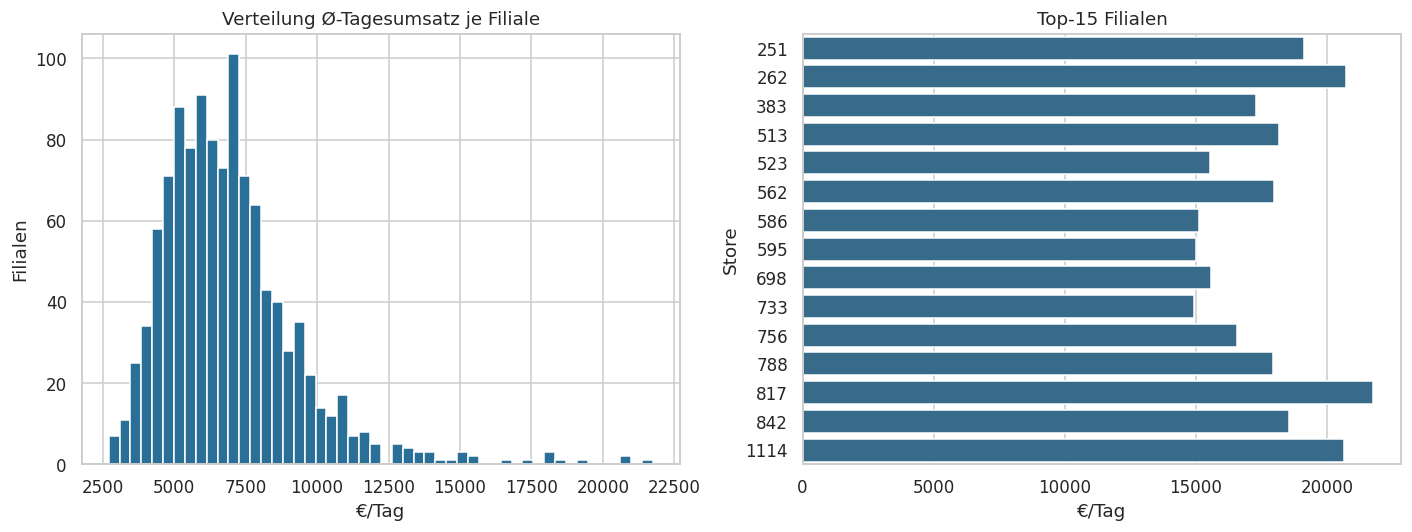

,Store,Umsatz_gesamt,Umsatz_pro_Tag,Kunden_pro_Tag,Bon_pro_Kunde,Offene_Tage,StoreType,Assortment,Wettbewerb_Naehe,Rang,Perzentil
816,817,17057867,"21,757.48","3,130.57",6.94,784,a,Basis,<500m,1,100.00
261,262,19516842,"20,718.52","3,402.01",6.06,942,b,Basis,500-1500m,2,99.90
1113,1114,16202585,"20,666.56","3,200.95",6.45,784,a,Erweitert,500-1500m,3,99.80
250,251,14896870,"19,123.07","2,450.49",7.77,779,a,Erweitert,<500m,4,99.70
841,842,11553523,"18,574.80","1,149.24",16.06,622,d,Erweitert,500-1500m,5,99.60
512,513,14252406,"18,179.09","2,096.34",8.63,784,a,Basis,<500m,6,99.60
561,562,16927322,"17,969.56","3,105.05",5.76,942,b,Erweitert,500-1500m,7,99.50
787,788,14082141,"17,961.91","1,717.90",10.44,784,a,Erweitert,1.5-5km,8,99.40
382,383,13489879,"17,294.72","2,205.45",7.81,780,a,Erweitert,<500m,9,99.30
755,756,12911782,"16,574.82","2,346.57",7.04,779,a,Erweitert,<500m,10,99.20


In [10]:
q1 = frame.groupby("Store").agg(
    Umsatz_gesamt=("Sales", "sum"), Umsatz_pro_Tag=("Sales", "mean"),
    Kunden_pro_Tag=("Customers", "mean"), Bon_pro_Kunde=("UmsatzProKunde", "mean"),
    Offene_Tage=("Sales", "count"), StoreType=("StoreType", "first"),
    Assortment=("Assortment_lbl", "first"),
    Wettbewerb_Naehe=("Wettbewerb_Naehe", "first")).reset_index()
q1["Rang"] = q1["Umsatz_pro_Tag"].rank(ascending=False).astype(int)
q1["Perzentil"] = (q1["Umsatz_pro_Tag"].rank(pct=True) * 100).round(1)
q1 = q1.sort_values("Umsatz_pro_Tag", ascending=False)
q1.to_csv(f"{OUTPUT_DIR}/q1_filial_ranking.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
q1["Umsatz_pro_Tag"].plot(kind="hist", bins=50, ax=ax[0], color="#2a6f97")
ax[0].set(title="Verteilung Ø-Tagesumsatz je Filiale", xlabel="€/Tag", ylabel="Filialen")
sns.barplot(data=q1.head(15), y="Store", x="Umsatz_pro_Tag", ax=ax[1], orient="h", color="#2a6f97")
ax[1].set(title="Top-15 Filialen", xlabel="€/Tag", ylabel="Store")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/q1_performance.png", bbox_inches="tight"); plt.show()
q1.head(10)

**Befund Q1:** Die Umsatzverteilung ist rechtsschief – wenige Top-Filialen
heben sich deutlich ab. Die Spanne zwischen der stärksten und schwächsten Filiale
beträgt etwa **Faktor 8**. Das Ranking (`q1_filial_ranking.csv`) ist die Basis,
um Top-Performer als Benchmark und schwache Filialen als Handlungsfelder zu
identifizieren.

### Q2 · Standortfaktoren: Wettbewerb & Lage

Zwei Blickwinkel: die **Korrelation** zwischen Wettbewerbsdistanz und Umsatz auf
Filialebene, und die **segmentierte** Betrachtung nach Distanzklassen. Beide
zusammen zeigen oft mehr als eine einzelne Kennzahl.

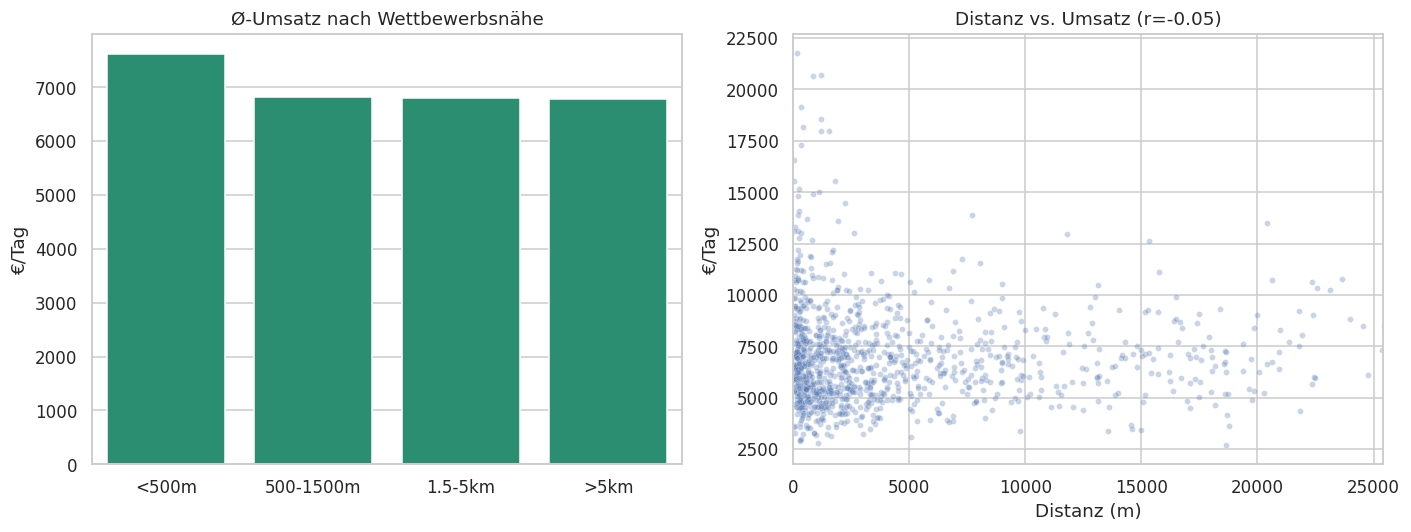

Korrelation Distanz <-> Umsatz: r = -0.054


,Wettbewerb_Naehe,Umsatz_pro_Tag,Kunden_pro_Tag,Filialen
0,<500m,"7,610.89",968.67,220
1,500-1500m,"6,825.41",820.41,213
2,1.5-5km,"6,790.37",712.40,330
3,>5km,"6,776.37",645.34,352


In [11]:
by_dist = frame.groupby("Wettbewerb_Naehe", observed=True).agg(
    Umsatz_pro_Tag=("Sales", "mean"), Kunden_pro_Tag=("Customers", "mean"),
    Filialen=("Store", "nunique")).reset_index()
per_store = frame.groupby("Store").agg(
    Umsatz_pro_Tag=("Sales", "mean"), CompetitionDistance=("CompetitionDistance", "first"))
corr = per_store["Umsatz_pro_Tag"].corr(per_store["CompetitionDistance"])
by_dist.to_csv(f"{OUTPUT_DIR}/q2_wettbewerb_distanz.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=by_dist, x="Wettbewerb_Naehe", y="Umsatz_pro_Tag", ax=ax[0], color="#1b9e77")
ax[0].set(title="Ø-Umsatz nach Wettbewerbsnähe", xlabel="", ylabel="€/Tag")
sns.scatterplot(data=per_store.reset_index(), x="CompetitionDistance", y="Umsatz_pro_Tag",
                ax=ax[1], alpha=0.3, s=15)
ax[1].set(title=f"Distanz vs. Umsatz (r={corr:.2f})", xlabel="Distanz (m)", ylabel="€/Tag")
ax[1].set_xlim(0, per_store["CompetitionDistance"].quantile(0.97))
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/q2_location.png", bbox_inches="tight"); plt.show()
print(f"Korrelation Distanz <-> Umsatz: r = {corr:.3f}")
by_dist

**Befund Q2:** Die lineare Korrelation ist nahezu null (r ≈ −0,05) – Distanz
allein erklärt den Umsatz *nicht*. Die Segmentansicht zeigt jedoch: Filialen mit
sehr nahem Wettbewerb (<500 m) haben im Schnitt den **höchsten** Umsatz. Erklärung:
Wettbewerber siedeln sich dort an, wo viel Kundenfrequenz herrscht (gute Lagen).
Die Lage dominiert also den reinen Wettbewerbseffekt – ein wichtiger Hinweis für
Standortentscheidungen.

### Q3 · Saisonalität: Monats- und Wochenmuster

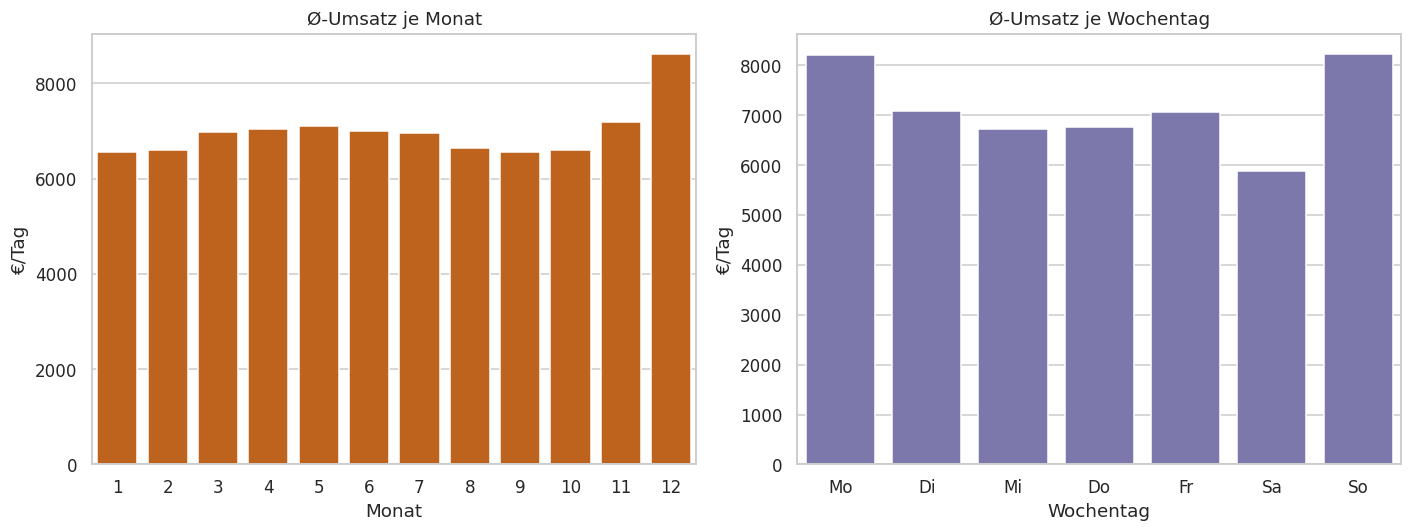

,Wochentag,Umsatz_pro_Tag,Kunden_pro_Tag
4,Mo,"8,216.25",855.46
0,Di,"7,088.41",770.02
3,Mi,"6,728.79",740.67
1,Do,"6,768.21",755.67
2,Fr,"7,073.03",781.81
5,Sa,"5,875.08",660.21
6,So,"8,224.72","1,441.53"


In [12]:
by_month = frame.groupby("Monat").agg(Umsatz_pro_Tag=("Sales", "mean")).reset_index()
by_dow = frame.groupby("Wochentag").agg(
    Umsatz_pro_Tag=("Sales", "mean"), Kunden_pro_Tag=("Customers", "mean")).reset_index()
by_dow["Wochentag"] = pd.Categorical(by_dow["Wochentag"], DOW_ORDER, ordered=True)
by_dow = by_dow.sort_values("Wochentag")
by_month.to_csv(f"{OUTPUT_DIR}/q3_saison_monat.csv", index=False, encoding="utf-8-sig")
by_dow.to_csv(f"{OUTPUT_DIR}/q3_saison_wochentag.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=by_month, x="Monat", y="Umsatz_pro_Tag", ax=ax[0], color="#d95f02")
ax[0].set(title="Ø-Umsatz je Monat", ylabel="€/Tag")
sns.barplot(data=by_dow, x="Wochentag", y="Umsatz_pro_Tag", ax=ax[1], color="#7570b3")
ax[1].set(title="Ø-Umsatz je Wochentag", ylabel="€/Tag")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/q3_seasonality.png", bbox_inches="tight"); plt.show()
by_dow

**Befund Q3:** Deutlicher **Dezember-Peak** (Weihnachtsgeschäft) und ein
Wochenmuster mit starkem Montag und – wo geöffnet – sehr hohen Sonntagsumsätzen
(seltene Öffnungstage mit hoher Frequenz). Samstag ist im Schnitt am schwächsten.
Das spricht für personal- und bestandsseitige Planung entlang dieser Muster.

### Q4 · Feiertage & Schulferien

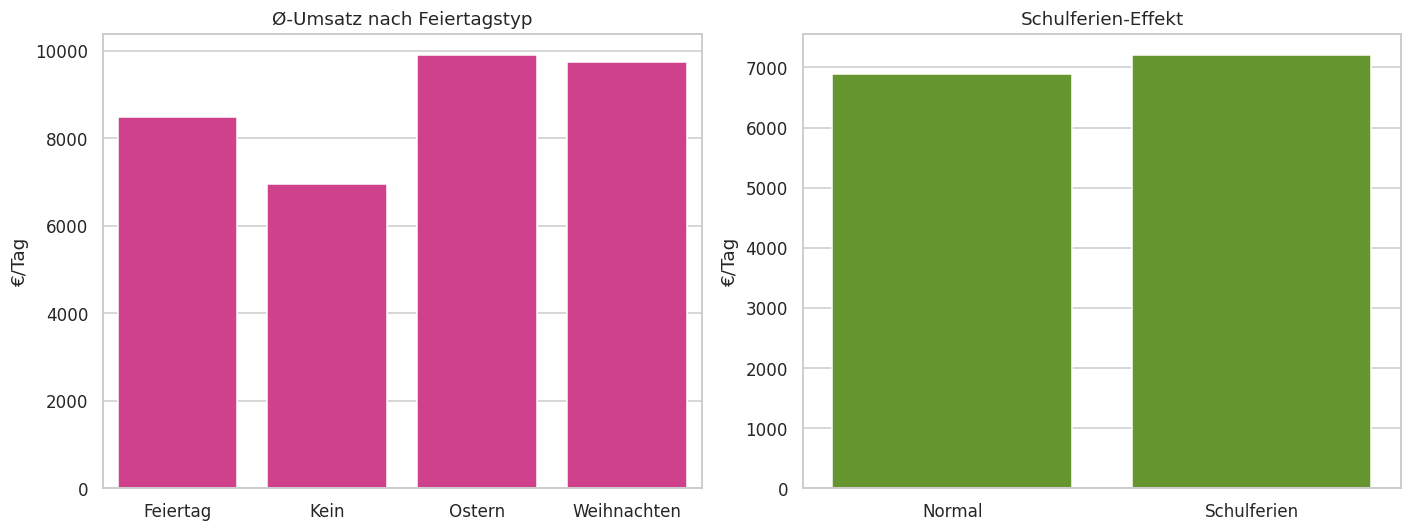

,Feiertag_lbl,Umsatz_pro_Tag,Tage,Uplift_%
0,Feiertag,"8,487.47",694,22.10
1,Kein,"6,953.96",843428,0.00
2,Ostern,"9,887.89",145,42.20
3,Weihnachten,"9,743.75",71,40.10


In [13]:
by_state = frame.groupby("Feiertag_lbl").agg(
    Umsatz_pro_Tag=("Sales", "mean"), Tage=("Sales", "count")).reset_index()
base = by_state.loc[by_state["Feiertag_lbl"] == "Kein", "Umsatz_pro_Tag"].iloc[0]
by_state["Uplift_%"] = ((by_state["Umsatz_pro_Tag"] / base - 1) * 100).round(1)
by_school = frame.groupby("Schulferien").agg(
    Umsatz_pro_Tag=("Sales", "mean"), Tage=("Sales", "count")).reset_index()
by_school["Schulferien"] = by_school["Schulferien"].map({0: "Normal", 1: "Schulferien"})
by_state.to_csv(f"{OUTPUT_DIR}/q4_feiertage.csv", index=False, encoding="utf-8-sig")
by_school.to_csv(f"{OUTPUT_DIR}/q4_schulferien.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=by_state, x="Feiertag_lbl", y="Umsatz_pro_Tag", ax=ax[0], color="#e7298a")
ax[0].set(title="Ø-Umsatz nach Feiertagstyp", xlabel="", ylabel="€/Tag")
sns.barplot(data=by_school, x="Schulferien", y="Umsatz_pro_Tag", ax=ax[1], color="#66a61e")
ax[1].set(title="Schulferien-Effekt", xlabel="", ylabel="€/Tag")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/q4_holidays.png", bbox_inches="tight"); plt.show()
by_state

**Befund Q4:** An geöffneten Tagen rund um **Ostern (+~42 %)** und
**Weihnachten (+~40 %)** liegt der Umsatz deutlich über dem Normalniveau – an den
*offenen* Tagen vor den Feiertagen bündelt sich die Nachfrage. Schulferien zeigen
einen moderaten Effekt. Wichtig: Dies betrifft Öffnungstage; an gesetzlichen
Feiertagen sind die meisten Filialen geschlossen.

### Q5 · Promotionen: Welche Aktionen wirken am besten?

Wir vergleichen Tage **mit vs. ohne Promo** (Uplift) und prüfen, ob die
Dauer-Promo *Promo2* einen Mehrwert bringt. Zusätzlich: Wo wirkt die Promo am
stärksten – nach Filialtyp?

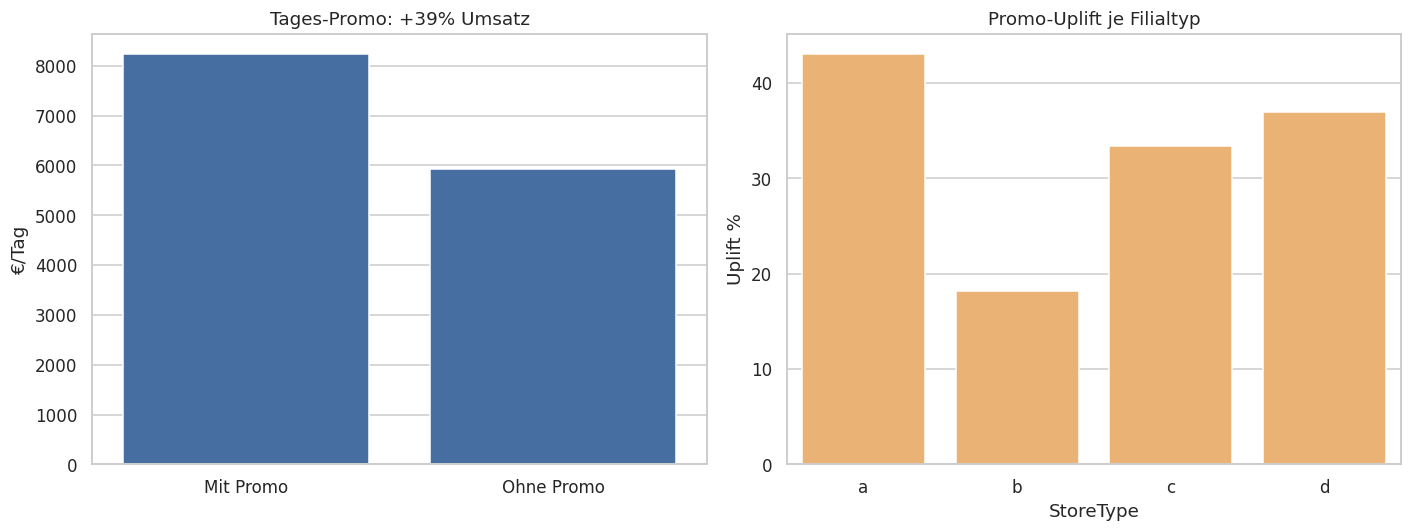

Durchschnittlicher Promo-Uplift: +38.8%


Promo_lbl,StoreType,Mit Promo,Ohne Promo,Uplift_%
0,a,"8,304.55","5,809.05",43.00
1,b,"11,311.80","9,567.86",18.20
2,c,"8,042.79","6,028.55",33.40
3,d,"8,018.04","5,855.39",36.90


In [14]:
by_promo = frame.groupby("Promo_lbl").agg(
    Umsatz_pro_Tag=("Sales", "mean"), Kunden_pro_Tag=("Customers", "mean"),
    Bon_pro_Kunde=("UmsatzProKunde", "mean")).reset_index()
with_p = by_promo.loc[by_promo["Promo_lbl"] == "Mit Promo", "Umsatz_pro_Tag"].iloc[0]
no_p   = by_promo.loc[by_promo["Promo_lbl"] == "Ohne Promo", "Umsatz_pro_Tag"].iloc[0]
uplift = (with_p / no_p - 1) * 100

promo_by_type = frame.pivot_table(index="StoreType", columns="Promo_lbl",
                                  values="Sales", aggfunc="mean")
promo_by_type["Uplift_%"] = ((promo_by_type["Mit Promo"]/promo_by_type["Ohne Promo"]-1)*100).round(1)
promo_by_type = promo_by_type.reset_index()
by_promo.to_csv(f"{OUTPUT_DIR}/q5_promo.csv", index=False, encoding="utf-8-sig")
promo_by_type.to_csv(f"{OUTPUT_DIR}/q5_promo_je_filialtyp.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=by_promo, x="Promo_lbl", y="Umsatz_pro_Tag", ax=ax[0], color="#386cb0")
ax[0].set(title=f"Tages-Promo: +{uplift:.0f}% Umsatz", xlabel="", ylabel="€/Tag")
sns.barplot(data=promo_by_type, x="StoreType", y="Uplift_%", ax=ax[1], color="#fdb462")
ax[1].set(title="Promo-Uplift je Filialtyp", ylabel="Uplift %")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/q5_promotions.png", bbox_inches="tight"); plt.show()
print(f"Durchschnittlicher Promo-Uplift: +{uplift:.1f}%")
promo_by_type

**Befund Q5:** Tages-Promotionen heben den Umsatz im Schnitt um **~39 %** –
der stärkste einzelne Hebel im Datensatz. Der Uplift fällt je Filialtyp
unterschiedlich aus (Typ a reagiert am stärksten). Das erlaubt gezieltes,
filialtyp-spezifisches Promo-Budgeting statt Gießkanne.

### Q6 · Filialtyp-Vergleich (StoreType × Sortiment)

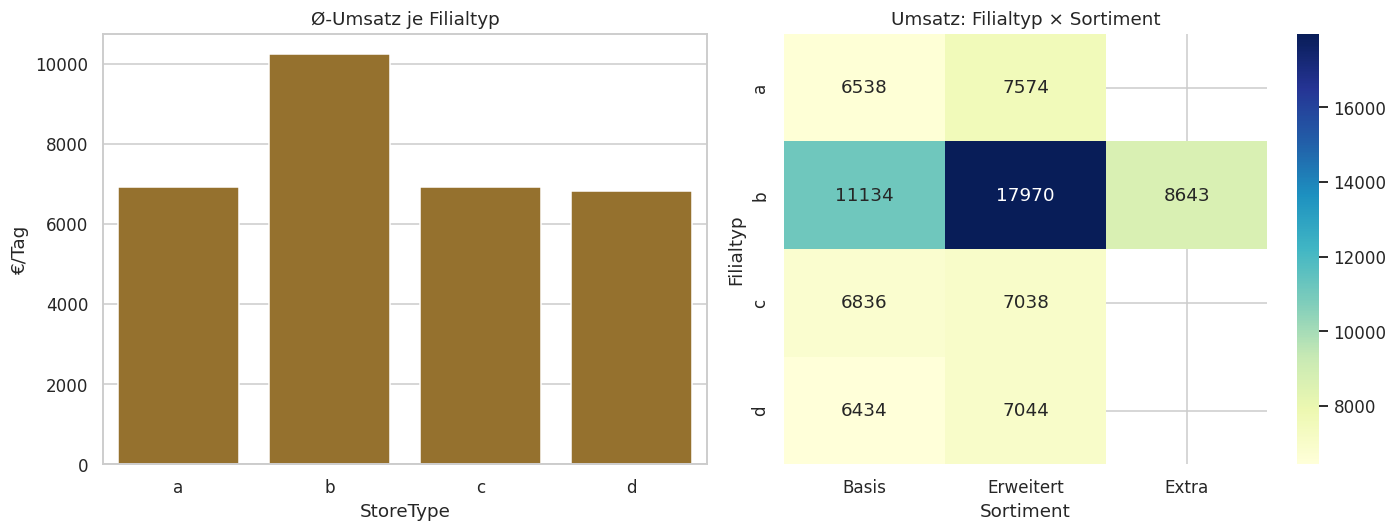

,StoreType,Umsatz_pro_Tag,Kunden_pro_Tag,Bon_pro_Kunde,Filialen
0,a,"6,925.70",795.42,8.85,602
1,b,"10,233.38","2,022.21",5.13,17
2,c,"6,933.13",815.54,8.63,148
3,d,"6,822.30",606.35,11.28,348


In [15]:
by_type = frame.groupby("StoreType").agg(
    Umsatz_pro_Tag=("Sales", "mean"), Kunden_pro_Tag=("Customers", "mean"),
    Bon_pro_Kunde=("UmsatzProKunde", "mean"), Filialen=("Store", "nunique")).reset_index()
cross = frame.pivot_table(index="StoreType", columns="Assortment_lbl",
                          values="Sales", aggfunc="mean").round(0)
by_type.to_csv(f"{OUTPUT_DIR}/q6_filialtyp.csv", index=False, encoding="utf-8-sig")
cross.reset_index().to_csv(f"{OUTPUT_DIR}/q6_filialtyp_x_sortiment.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=by_type, x="StoreType", y="Umsatz_pro_Tag", ax=ax[0], color="#a6761d")
ax[0].set(title="Ø-Umsatz je Filialtyp", ylabel="€/Tag")
sns.heatmap(cross, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[1])
ax[1].set(title="Umsatz: Filialtyp × Sortiment", xlabel="Sortiment", ylabel="Filialtyp")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/q6_storetype.png", bbox_inches="tight"); plt.show()
by_type

**Befund Q6:** Filialtyp **b** erzielt mit Abstand den höchsten Umsatz und
die höchste Kundenfrequenz, hat aber den **niedrigsten Bon pro Kunde** – ein
Großflächen-/Frequenzformat. Typ **d** dagegen hat den höchsten Bon pro Kunde.
Das Sortiment „Extra" (b) korreliert mit den höchsten Umsätzen. Die Strategie
sollte also je Format unterschiedlich sein: Frequenz vs. Warenkorbwert.

## 5 · Management-KPI-Cockpit

Verdichtung der wichtigsten Kennzahlen für die Geschäftsführung.

In [16]:
kpis = {
    "Gesamtumsatz (Mio €)":           round(frame["Sales"].sum() / 1e6, 1),
    "Ø-Tagesumsatz je Filiale (€)":   round(frame["Sales"].mean(), 0),
    "Ø-Kunden je Filiale/Tag":        round(frame["Customers"].mean(), 0),
    "Ø-Bon je Kunde (€)":             round(frame["UmsatzProKunde"].mean(), 2),
    "Promo-Uplift (%)":               round(uplift, 1),
    "Umsatzspanne Top/Flop (Faktor)": round(q1["Umsatz_pro_Tag"].max()/q1["Umsatz_pro_Tag"].min(), 1),
    "Anzahl Filialen":                int(frame["Store"].nunique()),
}
kpi = pd.DataFrame({"KPI": list(kpis), "Wert": list(kpis.values())})
kpi.to_csv(f"{OUTPUT_DIR}/kpi_management.csv", index=False, encoding="utf-8-sig")
kpi

,KPI,Wert
0,Gesamtumsatz (Mio €),"5,873.20"
1,Ø-Tagesumsatz je Filiale (€),"6,956.00"
2,Ø-Kunden je Filiale/Tag,763.00
3,Ø-Bon je Kunde (€),9.49
4,Promo-Uplift (%),38.80
5,Umsatzspanne Top/Flop (Faktor),8.00
6,Anzahl Filialen,"1,115.00"


## 6 · Export der Tableau-Master-Tabelle

Eine einzige, analyse-fertige CSV mit allen gejointen Quellen und abgeleiteten
Feldern. Diese Datei wird direkt in Tableau geladen.

In [17]:
master.to_csv(f"{OUTPUT_DIR}/rossmann_master_tableau.csv", index=False, encoding="utf-8-sig")
print(f"Exportiert: {OUTPUT_DIR}/rossmann_master_tableau.csv")
print(f"{master.shape[0]:,} Zeilen × {master.shape[1]} Spalten")
print("Spalten:", ", ".join(master.columns))

Exportiert: ./output/rossmann_master_tableau.csv
1,017,209 Zeilen × 34 Spalten
Spalten: Store, DayOfWeek, Date, Sales, Customers, Open, Promo, StateHoliday, SchoolHoliday, Jahr, Monat, MonatName, KW, Quartal, JahrMonat, Wochentag, IstWochenende, Feiertag_lbl, Promo_lbl, Schulferien, StoreType, Assortment, CompetitionDistance, CompetitionOpenSinceMonth, CompetitionOpenSinceYear, Promo2, Promo2SinceWeek, Promo2SinceYear, PromoInterval, Assortment_lbl, Wettbewerb_Naehe, Wettbewerb_aktiv, Promo2_aktiv, UmsatzProKunde


## 7 · Management Summary & Handlungsempfehlungen

**Kernbefunde**

| Frage | Erkenntnis |
|-------|-----------|
| Q1 Performance | Umsatzspanne ~Faktor 8; wenige Top-Filialen, rechtsschiefe Verteilung |
| Q2 Standort | Distanz allein erklärt Umsatz nicht (r≈−0,05); Lage/Frequenz dominiert |
| Q3 Saison | Dezember-Peak; starker Mo & So, schwacher Sa |
| Q4 Feiertage | Ostern/Weihnachten +~40 % an Öffnungstagen |
| Q5 Promo | Tages-Promo +~39 % – stärkster Hebel; wirkt je Filialtyp unterschiedlich |
| Q6 Filialtyp | Typ b = Frequenzformat (hoher Umsatz, niedriger Bon); Typ d = hoher Bon |

**Empfehlungen**

1. **Promo gezielt steuern:** Den ~39 %-Hebel filialtyp-spezifisch einsetzen
   (Typ a reagiert am stärksten) statt pauschal – Budget dorthin lenken, wo der
   Uplift am größten ist.
2. **Schwache Filialen mit Top-Performern benchmarken:** Filialen im untersten
   Perzentil gegen vergleichbare Top-Filialen (gleicher Typ/Lage) spiegeln und
   konkrete Lücken (Frequenz vs. Bon) schließen.
3. **Saisonale Planung:** Personal, Bestand und Aktionen entlang Dezember-Peak
   und Wochenprofil ausrichten.
4. **Standortbewertung verfeinern:** Nicht die reine Wettbewerbsdistanz, sondern
   Lage-/Frequenzindikatoren in die Bewertung neuer Standorte aufnehmen.

> *Nächste Ausbaustufe:* Mit Wetter- und Google-Trends-Daten lassen sich
> Nachfrageprognosen und Wettereffekte ergänzen – die Pipeline bindet beide
> Quellen automatisch ein, sobald sie vorliegen.